In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("netflix_titles_final_clean.csv");

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8793 entries, 0 to 8792
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   show_id            8793 non-null   object 
 1   type               8793 non-null   object 
 2   title              8793 non-null   object 
 3   director           8793 non-null   object 
 4   cast               8793 non-null   object 
 5   country            8793 non-null   object 
 6   date_added         8793 non-null   object 
 7   release_year       8793 non-null   int64  
 8   rating             8793 non-null   object 
 9   listed_in          8793 non-null   object 
 10  description        8793 non-null   object 
 11  duration_minutes   6126 non-null   float64
 12  duration_episodes  2664 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 893.2+ KB
None


In [4]:
print(df.head(5))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating  \
0  September 25, 2021          2020  PG-13   
1  September 24, 2021          2021  TV-MA   
2  September 24, 2021          2021  TV-MA   
3  September 24,

In [5]:
print(df.describe());
#4. đếm số giá trị duy nhất của biến phân loại
print(df[['type','country','rating','listed_in']].nunique())

       release_year  duration_minutes  duration_episodes
count   8793.000000       6126.000000        2664.000000
mean    2014.183100         99.584884           1.751877
std        8.824128         28.283225           1.550622
min     1925.000000          3.000000           1.000000
25%     2013.000000         87.000000           1.000000
50%     2017.000000         98.000000           1.000000
75%     2019.000000        114.000000           2.000000
max     2021.000000        312.000000          17.000000
type           2
country      749
rating        17
listed_in    513
dtype: int64


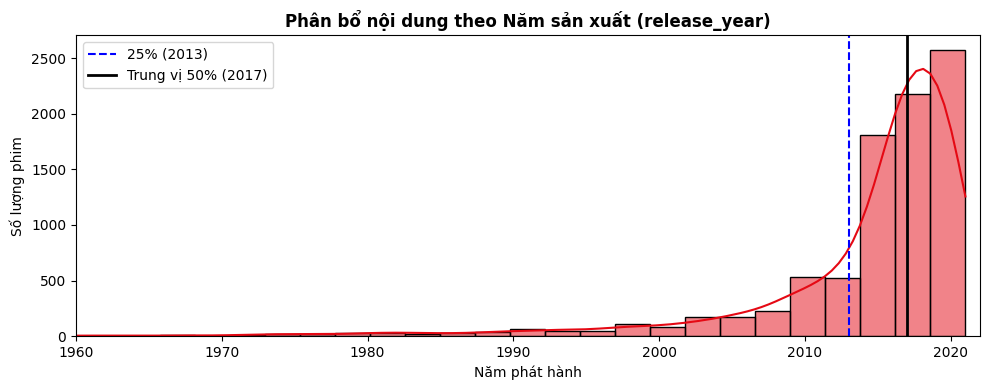

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(df['release_year'], bins=40, kde=True, color='#E50914')

# Đánh dấu các mốc quan trọng
plt.axvline(2013, color='blue', linestyle='--', label='25% (2013)')
plt.axvline(2017, color='black', linestyle='-', linewidth=2, label='Trung vị 50% (2017)')

plt.title('Phân bổ nội dung theo Năm sản xuất (release_year)', fontsize=12, fontweight='bold')
plt.xlabel('Năm phát hành')
plt.ylabel('Số lượng phim')
plt.xlim(1960, 2022)  # Cắt góc nhìn từ 1960 để thấy rõ khối lượng tập trung giai đoạn gần đây
plt.legend()
plt.tight_layout()
plt.show()

Tóm lại:
    - Dữ liệu bao quát các tác phẩm đc sản xuất trải dài từ năm 1925 đến 2021
    - Danh mục Netflix tập trung áp đảo vào các tác phậm hiện đại , khi mà có tới 75% số lượng phim đc sản xuất sau năm 2013, và hơn 50% toàn bộ kho phim là được ra đời trong gian đoạn 2017-2021
    --> Chiến lược của NetFlix là ưu tiên nội dung mới để có thể thu hút và giữ chân khách hàng

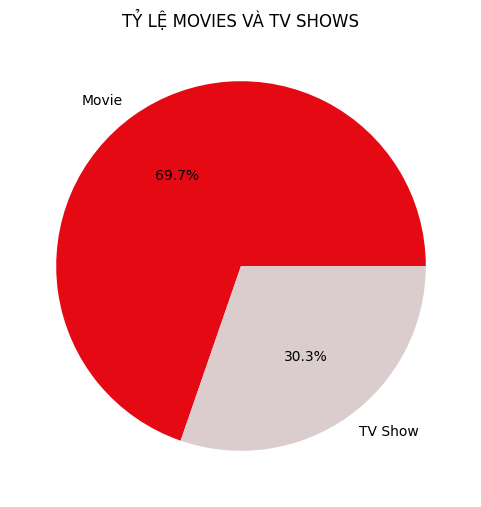

In [13]:
#Xét cơ cấu phim lẻ và phim Bộ
import seaborn as sns
import matplotlib.pyplot as plt
#đếm tỷ lệ
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_counts,
        labels=type_counts.index,
        autopct='%1.1f%%', 
        colors=['#E50914',"#DBCDCD"])
plt.title("TỶ LỆ MOVIES VÀ TV SHOWS")
plt.show()

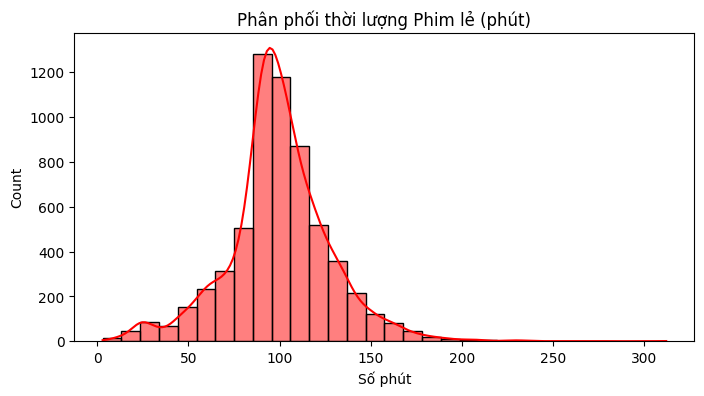

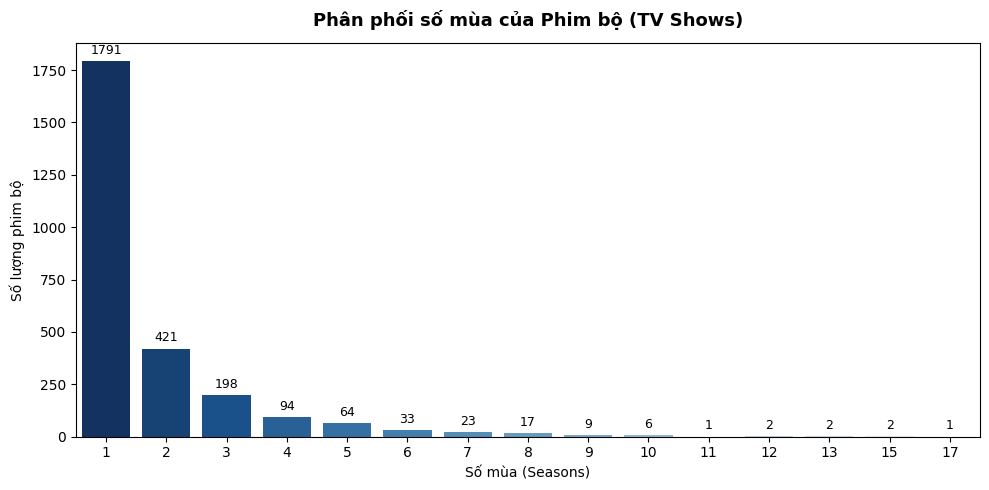

Tỷ lệ phim bộ chỉ có 1 mùa: 67.2%


In [ ]:
# Với Movie: vẽ histogram kiểm tra phân phối thời lượng phút
movie_df = df[df['type'] == 'Movie'].copy()
plt.figure(figsize=(8, 4))
sns.histplot(movie_df['duration_minutes'], bins=30, kde=True, color='red')
plt.title('Phân phối thời lượng Phim lẻ (phút)')
plt.xlabel('Số phút')
plt.show()

# Với TV Show: đếm số mùa
tv_df = df[df['type'] == 'TV Show'].copy()

# Đảm bảo cột seasons ở dạng số nguyên để sắp xếp đúng thứ tự từ 1 trở lên
tv_df['seasons'] = tv_df['duration_episodes'].astype(int)
order_seasons = sorted(tv_df['seasons'].unique())

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=tv_df, 
    x='seasons', 
    order=order_seasons, 
    palette='Blues_r',
    hue='seasons',
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.title('Phân phối số mùa của Phim bộ (TV Shows)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Số mùa (Seasons)')
plt.ylabel('Số lượng phim bộ')
plt.tight_layout()
plt.show()

# Tính nhanh tỷ lệ % các phim chỉ có 1 mùa
season_1_pct = (tv_df['seasons'] == 1).mean() * 100
print(f"Tỷ lệ phim bộ chỉ có 1 mùa: {season_1_pct:.1f}%")

C:\Users\Admin\AppData\Local\Temp\ipykernel_25716\1676312243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='rating',


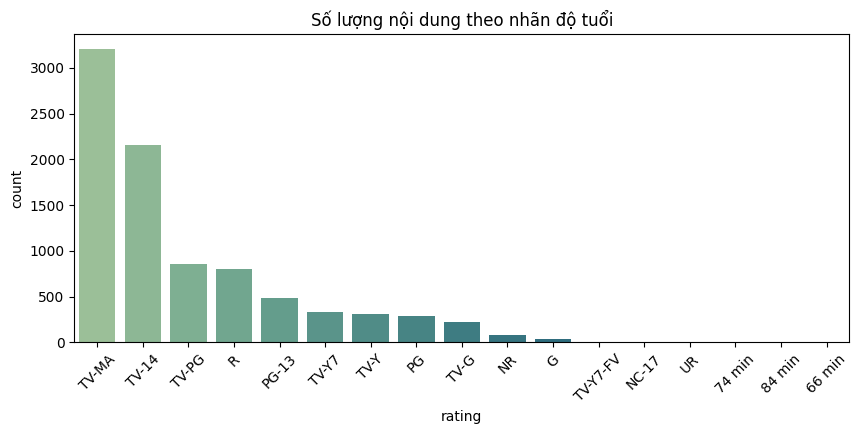

In [29]:
#phân loại khách theo độ tuổi
plt.figure(figsize=(10,4))
sns.countplot(data=df,x='rating',
              order= df['rating'].value_counts().index,palette='crest')
plt.title("Số lượng nội dung theo nhãn độ tuổi")
plt.xticks(rotation = 45)
plt.show()

Tóm lại :
    - Cơ cấu sản phẩm: Phim lẻ chiếm tỷ trọng vượt trội 69,7% so với 30,3% của Phim bộ.
    - Thời lượng vàng (Movie): Tập trung phổ biến từ 87 – 114 phút (trung bình ~99,6 phút)..
    - Sự ưu tiên :
        1.TV-MA(36,45%)
        2.TV-14(24,53%)
        3.TV-PG(9,79%)
        4.R(9,09%)

In [31]:
#3:phân tích 2 biến và đa biến
genre_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

#bung cột quốc gia
country_df = df.assign(country = df['country'].str.split(', ')).explode('country')
country_df = country_df[country_df['country'].notna()]

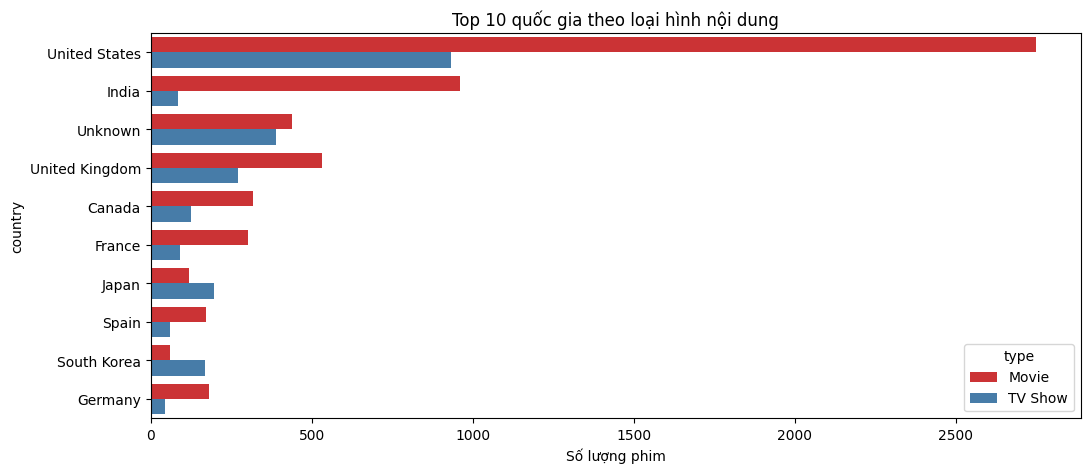

In [32]:
top_countries = country_df['country'].value_counts().head(10).index
country_top_df = country_df[country_df['country'].isin(top_countries)]
plt.figure(figsize=(12, 5))
sns.countplot(data=country_top_df, y='country', hue='type', order=top_countries, palette='Set1')
plt.title('Top 10 quốc gia theo loại hình nội dung')
plt.xlabel('Số lượng phim')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_25716\408140704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movie_genres.values, y=top_movie_genres.index, ax=axes[0], palette='Reds_r')
C:\Users\Admin\AppData\Local\Temp\ipykernel_25716\408140704.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tv_genres.values, y=top_tv_genres.index, ax=axes[1], palette='Blues_r')


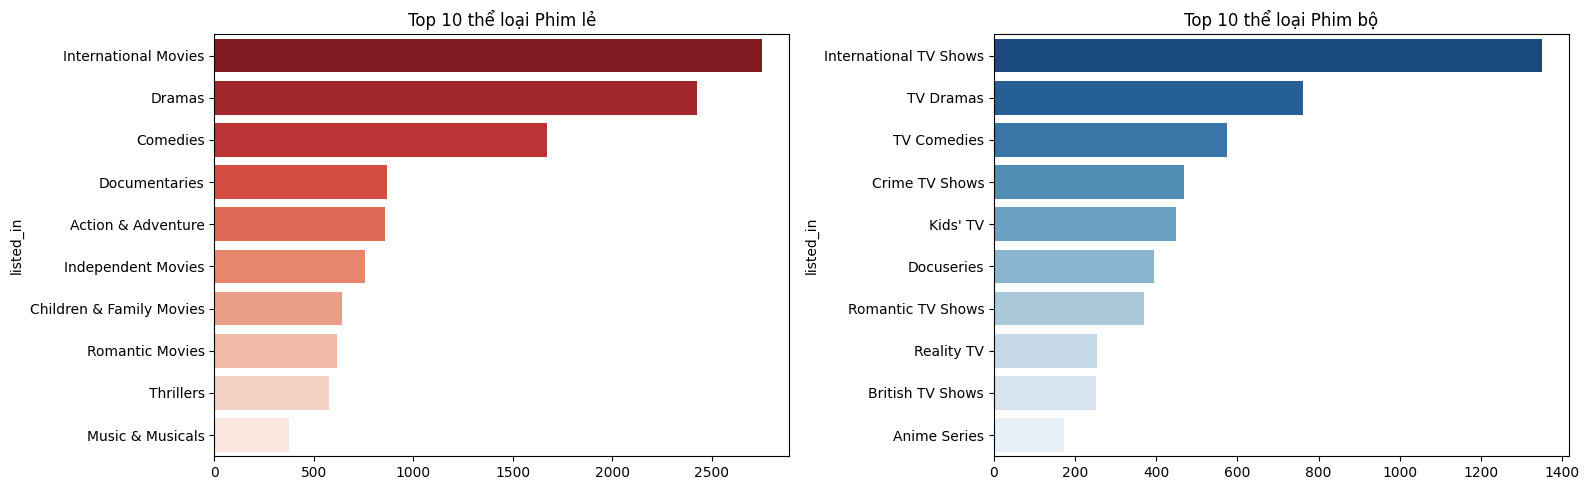

In [34]:
# Top 10 thể loại Movie
top_movie_genres = genre_df[genre_df['type'] == 'Movie']['listed_in'].value_counts().head(10)

# Top 10 thể loại TV Show
top_tv_genres = genre_df[genre_df['type'] == 'TV Show']['listed_in'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_movie_genres.values, y=top_movie_genres.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 thể loại Phim lẻ')

sns.barplot(x=top_tv_genres.values, y=top_tv_genres.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 thể loại Phim bộ')
plt.tight_layout()
plt.show()

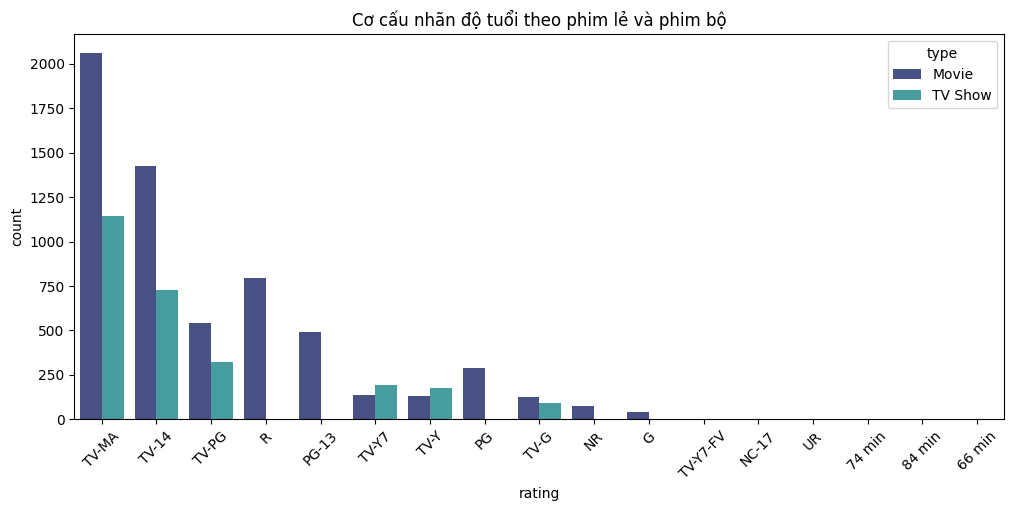

In [38]:
# Nhãn độ tuổi theo loại hình (ratings và type)
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='rating',
              hue = 'type', order=df['rating'].value_counts().index,palette='mako')
plt.title("Cơ cấu nhãn độ tuổi theo phim lẻ và phim bộ")
plt.xticks(rotation = 45)
plt.show()

Tóm lại:
    -Mỹ đóng vai trò thị trường nguồn lớn nhất với 3.683 tác phẩm, duy trì phát trieent với 74,7% phim lẻ và 25,3% phim bộ
    - Ấn Độ là trung tâm cung cấp phim điện ảnh lớn thứ hai với 1.046 tác phẩm, trong đó Phim lẻ chiếm ưu thế áp đảo (92,0%).
    - Trái lại, các thị trường Đông Á như Hàn Quốc (73,6%) và Nhật Bản (62,3%) lại tập trung chủ yếu vào Phim bộ (TV Shows, K-Dramas và Anime). Đây là nhóm nội dung có giá trị giữ chân thuê bao dài hạn rất cao.

In [ ]:
#4 : phân tích chuỗi thời gian 

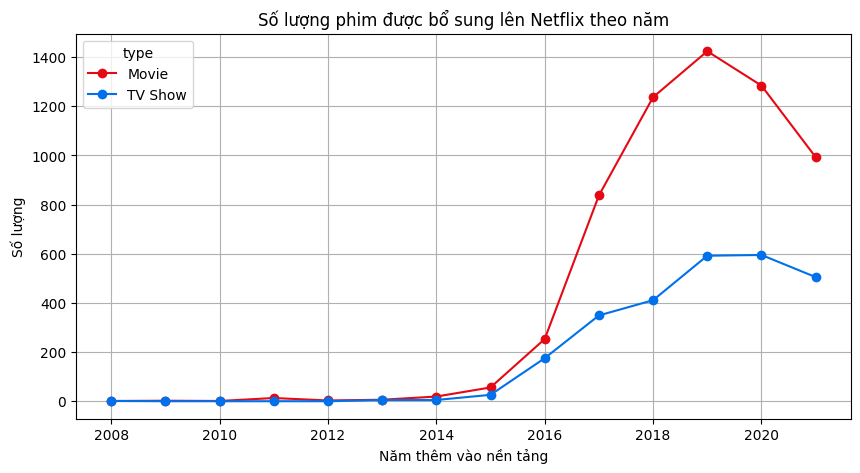

In [41]:
#Tốc độ thêm phim mới qua các năm
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
trend_data = df.groupby(['year_added','type']).size().unstack().fillna(0)
trend_data.plot(kind='line', marker='o', figsize=(10, 5), color=['#E50914', '#0071EB'])
plt.title('Số lượng phim được bổ sung lên Netflix theo năm')
plt.xlabel('Năm thêm vào nền tảng')
plt.ylabel('Số lượng')
plt.grid(True)
plt.show()

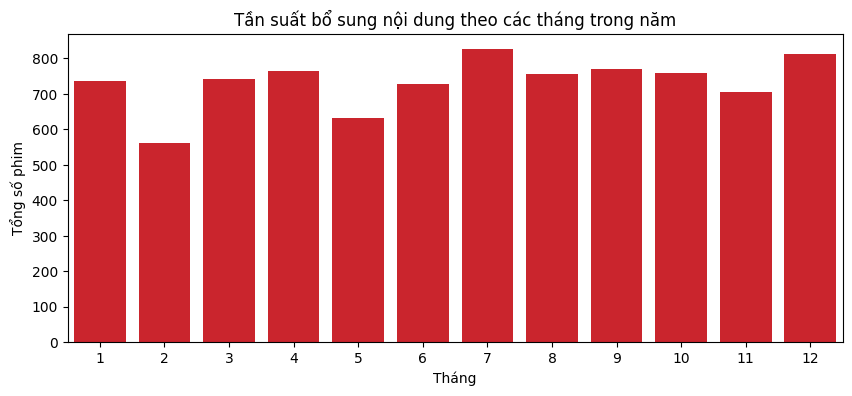

In [42]:
df['month_added'] = df['date_added'].dt.month
monthly_trend = df['month_added'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_trend.index, y=monthly_trend.values, color='#E50914')
plt.title('Tần suất bổ sung nội dung theo các tháng trong năm')
plt.xlabel('Tháng')
plt.ylabel('Tổng số phim')
plt.show()

Tóm lại:
    - Tăng trưởng bùng nổ (2016 – 2019): Lượng phim bổ sung tăng gần 5 lần, đạt đỉnh vào năm 2019 (2.016 tác phẩm); lượng Movie luôn gấp 2 – 3 lần TV Show để mở rộng nhanh quy mô kho phim. (Số liệu 2021 giảm do dữ liệu chỉ thu thập đến tháng 9/2021).
    - Ưu tiên nội dung mới: 55% tác phẩm được đưa lên nền tảng trong vòng 1 năm kể từ khi sản xuất (trong đó 36,9% lên sóng ngay trong năm ra mắt), khẳng định sự dịch chuyển sang phim mới và Netflix Originals
    - Quốc tế hóa mạnh mẽ: Nội dung từ các thị trường trọng điểm như Ấn Độ, Hàn Quốc và Nhật Bản tăng vọt gấp 5 đến 20 lần trong giai đoạn 2017 – 2020, phản ánh rõ chiến lược bành trướng nội dung phi tiếng Anh.
